In [1]:
##Introduction
# In this project we will be analyzing the U.S. quarterly GDP growth rates
#from 2010 to 2023 as reported by the U.S. Bureau of Economic Analysis (BEA).
#More specifically, we will be looking at the impact
#COVID-19 had on the GDP. We will be using least squares linear regression,
#polynomial fitting, and cubic spline interpolation. Additionally, we will
#be comparing interpolation and approximation to see which method would best 
#represent the trends that are being observed.

In [2]:
#Put in the data
import numpy as np
import matplotlib.pyplot as plt

quarters = np.arange(1, 21)

gdp_growth = np.array([
    1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
    1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3
])

In [3]:
def evaluate(y, y_pred):
    mse = np.mean((y - y_pred)**2)

    ss_total = np.sum((y - np.mean(y))**2)
    ss_residual = np.sum((y - y_pred)**2)

    r2 = 1 - ss_residual / ss_total

    return mse, r2


def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred)**2))

In [4]:
def thomas_algorithm(a, b, c, d):
    n = len(b)

    for i in range(1, n):
        w = a[i-1] / b[i-1]   # FIXED
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]

    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]

    return x

In [5]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n - 3)
    B = np.zeros(n - 2)
    C = np.zeros(n - 3)
    D = np.zeros(n - 2)

    for i in range(1, n - 1):
        idx = i - 1

        B[idx] = 2 * (h[i-1] + h[i])
        D[idx] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])

        if idx > 0:
            A[idx - 1] = h[i-1]

        if idx < n - 3:
            C[idx] = h[i]

    return A, B, C, D

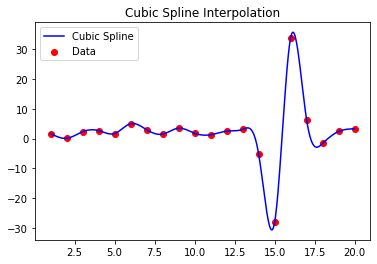

In [6]:
def evaluate_spline(x, y, M, x_eval):
    n = len(x)
    h = np.diff(x)
    y_eval = []

    for val in x_eval:
        dx = np.searchsorted(x, val) - 1
        dx = max(0, min(dx, n - 2))

        hi = h[dx]
        a = x[dx+1] - val
        b = val - x[dx]

        s = (M[dx] * a**3) / (6*hi)
        s += (M[dx+1] * b**3) / (6*hi)
        s += (y[dx]/hi - M[dx]*hi/6) * a
        s += (y[dx+1]/hi - M[dx+1]*hi/6) * b

        y_eval.append(s)

    return np.array(y_eval)

#Needed help from ChatGPT to debug my index being out of bounds which it told me that I needed
#to change the length of c.
A, B, C, D = setup_tridiagonal_matrix(quarters, gdp_growth)
M_internal = thomas_algorithm(A, B, C, D)

M = np.zeros(len(quarters))
M[1:-1] = M_internal

x_fine = np.linspace(1, 20, 500)
y_spline = evaluate_spline(quarters, gdp_growth, M, x_fine)

plt.scatter(quarters, gdp_growth, color='r', label="Data")
plt.plot(x_fine, y_spline, color='b', label="Cubic Spline")
plt.legend()
plt.title("Cubic Spline Interpolation")
plt.show()

Polynomial Fit
Coefficients: [-4.13737100e+00  4.44241917e+00 -8.23719896e-01  5.44711952e-02
 -1.17213791e-03]
MSE: 99.30773796212364
R^2: 0.016632392138785312


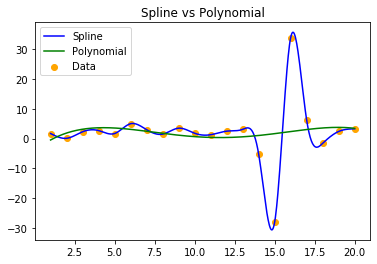

In [7]:
def build_vandermonde(x, degree):
    V = np.zeros((len(x), degree + 1))

    for i in range(degree + 1):
        V[:, i] = x**i

    return V


def vandermonde_fit(x, y, degree):
    V = build_vandermonde(x, degree)

    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, y)

    coeff = np.linalg.solve(VT_V, VT_y)

    return coeff


def eval_poly(coeff, x):
    y_pred = np.zeros(len(x))

    for i in range(len(coeff)):
        y_pred += coeff[i] * x**i

    return y_pred

degree = 4

coeff = vandermonde_fit(quarters, gdp_growth, degree)

y_poly = eval_poly(coeff, quarters)
y_poly_fine = eval_poly(coeff, x_fine)

mse_poly, r2_poly = evaluate(gdp_growth, y_poly)

print("Polynomial Fit")
print("Coefficients:", coeff)
print("MSE:", mse_poly)
print("R^2:", r2_poly)
plt.scatter(quarters, gdp_growth, color='orange', label="Data")
plt.plot(x_fine, y_spline, color='b', label="Spline")
plt.plot(x_fine, y_poly_fine, color="g", label="Polynomial")
plt.legend()
plt.title("Spline vs Polynomial")
plt.show()

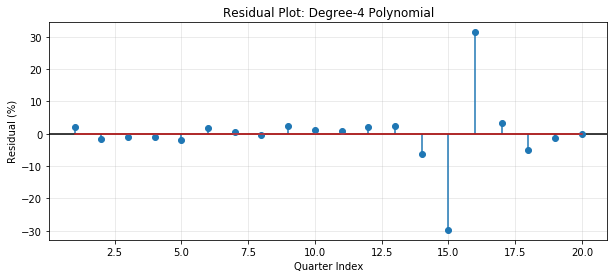

In [8]:
#ChatGPT caught that I forgot to include the residuals, additionally it showed me how to do a stem plot!
residuals_poly = gdp_growth - y_poly
plt.figure(figsize=(10, 4))
plt.axhline(0, color='black')
plt.stem(quarters, residuals_poly, use_line_collection=True)
plt.title("Residual Plot: Degree-4 Polynomial")
plt.xlabel("Quarter Index")
plt.ylabel("Residual (%)")
plt.grid(True, alpha=0.3)
plt.show()

Least Squares
Slope: -0.0173364485981308
Intercept: 2.3041121495327097
MSE: 2.0736612149532707
R^2: 0.004822992655011293


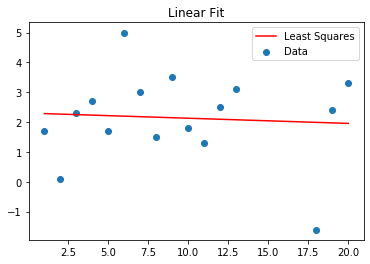

In [9]:
def custom_least_squares(X, Y):

    n = len(X)

    sum_x = np.sum(X)
    sum_y = np.sum(Y)
    sum_x2 = np.sum(X**2)
    sum_xy = np.sum(X * Y)

    denom = n * sum_x2 - sum_x**2

    m = (n * sum_xy - sum_x * sum_y) / denom
    b = (sum_y - m * sum_x) / n

    return m, b
#Used ChatGPT to tie all of this together referencing my old code which pointed me to using the mask function.

mask = ~np.isin(quarters, [14, 15, 16, 17])

x_no = quarters[mask]
y_no = gdp_growth[mask]

m, b = custom_least_squares(x_no, y_no)

y_linear = m * x_no + b

mse_linear, r2_linear = evaluate(y_no, y_linear)

print("Least Squares")
print("Slope:", m)
print("Intercept:", b)
print("MSE:", mse_linear)
print("R^2:", r2_linear)
plt.scatter(x_no, y_no, label="Data")
plt.plot(x_no, y_linear, color='r', label="Least Squares")
plt.legend()
plt.title("Linear Fit")
plt.show()

In [10]:
rmse_spline = rmse(gdp_growth, evaluate_spline(quarters, gdp_growth, M, quarters))
rmse_poly = rmse(gdp_growth, y_poly)
rmse_linear = rmse(y_no, y_linear)

V = build_vandermonde(quarters, degree)
cond = np.linalg.cond(np.dot(V.T, V))

print("RMSE Spline:", rmse_spline)
print("RMSE Polynomial:", rmse_poly)
print("RMSE Linear:", rmse_linear)
print("Condition Number:", cond)

RMSE Spline: 1.589609576479376e-15
RMSE Polynomial: 9.96532678651953
RMSE Linear: 1.4400212550352411
Condition Number: 233249125598.27863


In [11]:
# Write-Up Portion

##Cubic Spline Interpolation
#The cubic spline connects all of the data points with one smooth and continuous
#function. Additionally, the spline makes it easy to estimate the values between points.
#This roughly paints out how the GDP growth is behaving, and it does an excellent job at displaying how 
#aggressively the GDP is changing over time. However, because of the aggressive changes that are seen in
#2020, the spikes in data are also reflected by a wildly behaving spline shape. This creates the large 
#spikes that we see in the data before it stabilizes again.

##Polynomial and Least Squares
#The polynomial fit makes it easy to see the general movement of the data, but it does not show the exact values or
#how extreme the changes are in the data. On the other hand, least squares shows only a straight line, which entirely
#smoothes out any accurate reflection of point to point changes. There is no way to identify if there were extreme
#changes as seen in the actual data points, or if it just very slightly decreased over time. The spline would be best
#used if we wanted to see accurate reflections of how the data changes quarter to quarter, we can use poly. fit
#to see the changes in slight movements, and lastly, use least squares to just see how the data averages over
#the entire span of the data.

##Method Justification
#The cubic spline would be the best method for accurately reflecting GDP growth and decline, as it preserves the 
#actual data points and puts it into an easily trackable line that both professionals and the general public
#can interpret.

#Conclusion
#Although the cubic spline is prone to outlying data points, it does the best job at interpolation due to its
#ability to accurately reflect the actual local data and does so in a constant and continuous line. The polynomial
#fit would be the second best as it showed the changes in trends, but because of how extreme the changes were in
#2020, the other trends before and after were hardly distinguishable. Lastly, the least squares method did not 
#reflect the actual data points accurately enough to make any use from it on how the GDP changed year to year, let
#alone quarterly. Thus, cubic spline is the best for making estimations of the data points and thus the behavior
#between points. Polynomial fitting and least squares are best for just seeing very generalized views of the data.